<!-- codex-purpose-v2 -->
# 08 - V3 SAM Refinement Diagnostic

## Purpose
Test SAM-based mask refinement from GradCAM++ prompts and diagnose whether it
improves lesion boundaries.

## Research Thinking
- SAM can produce clean object masks, but point prompts often segment the whole
  leaf instead of the lesion.
- This notebook is kept because it documents an important negative/diagnostic
  result.
- The result motivates two-sided coverage guards and the later V5 color-prior
  strategy.

## Inputs / Outputs
- Input: V2 pseudo masks, raw images, and SAM checkpoint.
- Output: `data/sam_refined_labels_v3_train/`, V3 metrics, and coverage
  diagnostics.

## How To Read The Result
Present V3 as a diagnostic branch, not the final method. Its value is showing
why unconstrained SAM refinement is risky.


# 08 · Segmentation Model v3 — SAM Refinement + UNet++

Cải tiến so với notebook 07 (v2):
- **SAM Refinement**: Segment Anything Model (ViT-B) refine pseudo-labels v2 → boundary chính xác hơn
  - Extract centroid + sampled FG points + BG negative points từ mỗi mask
  - Two-sided guard: fallback về GradCAM++ nếu SAM drift hoặc coverage phình/teo quá mức
  - Post-process: CC filter + morphological close để loại noise
  - Kết quả lưu vào `sam_refined_labels_v3_train/` (resume được nếu bị ngắt)
- **Model**: UNet++ EfficientNet-B0 (giống v2 — so sánh công bằng, chỉ thay labels)
- **Loss / Optimizer**: FocalDice + AdamW + CosineAnnealing (giống v2)
- **Benchmark**: V1 vs V2 vs V3 cuối notebook

**Output**: `visualizations/segmentation_v3/`

In [1]:
import subprocess, sys

def ensure_installed(pip_name, import_name=None):
    import_name = import_name or pip_name.replace('-', '_')
    try:
        __import__(import_name)
        print(f'[OK] {pip_name}')
    except ImportError:
        print(f'Installing {pip_name}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pip_name, '-q'])
        print(f'[Installed] {pip_name}')

ensure_installed('segment-anything', 'segment_anything')
ensure_installed('segmentation-models-pytorch', 'segmentation_models_pytorch')
ensure_installed('albumentations')

[OK] segment-anything


[OK] segmentation-models-pytorch


[OK] albumentations


E:\Master\thesis-clean\venv\Lib\site-packages\albumentations\check_version.py:147: UserWarning: Error fetching version info <urlopen error [WinError 10013] An attempt was made to access a socket in a way forbidden by its access permissions>
  data = fetch_version_info()


In [2]:
import os, sys, json, urllib.request

proj_root = r'e:\Master\thesis-clean'
sys.path.insert(0, proj_root)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from PIL import Image
from torch.utils.data import Dataset, DataLoader, Subset

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
from segment_anything import sam_model_registry, SamPredictor

plt.style.use('default')
sns.set_palette("husl")

CLASS_NAMES  = ["ALGAL_LEAF_SPOT","ALLOCARIDARA_ATTACK","HEALTHY_LEAF","LEAF_BLIGHT","PHOMOPSIS_LEAF_SPOT"]
CLASS_LABELS = ["Algal Leaf Spot","Allocaridara Attack","Healthy Leaf","Leaf Blight","Phomopsis Leaf Spot"]
CLASS_COLORS = ["#E69F00","#56B4E9","#009E73","#0072B2","#D55E00"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_LABEL = {i: label for i, label in enumerate(CLASS_LABELS)}

VIZ_DIR = os.path.join(proj_root, "visualizations", "segmentation_v3")
os.makedirs(VIZ_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('proj_root:', proj_root)
print('VIZ_DIR  :', VIZ_DIR)

device: cuda
proj_root: e:\Master\thesis-clean
VIZ_DIR  : e:\Master\thesis-clean\visualizations\segmentation_v3


## 1) SAM Setup — tải checkpoint & load model

**Reasoning**: SAM ViT-B (~375MB) là vision foundation model cho zero-shot segmentation. Dùng point prompts (centroid + sampled FG + BG negative) thay vì bbox để kiểm soát tốt hơn vùng được segment. IoU guard (min_iou=0.15) tránh trường hợp SAM "drift" sang object khác.

In [3]:
SAM_CKPT_DIR  = os.path.join(proj_root, 'notebooks', 'models', 'sam')
os.makedirs(SAM_CKPT_DIR, exist_ok=True)

SAM_CKPT_PATH = os.path.join(SAM_CKPT_DIR, 'sam_vit_b_01ec64.pth')
SAM_URL       = 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth'

if not os.path.exists(SAM_CKPT_PATH):
    print('Downloading SAM ViT-B checkpoint (~375 MB)...')
    def _progress(b, bs, total):
        if b % 200 == 0:
            pct = min(100, b * bs * 100 / total)
            print(f'  {pct:.1f}%  ({b*bs/1e6:.0f}/{total/1e6:.0f} MB)', end='\r')
    urllib.request.urlretrieve(SAM_URL, SAM_CKPT_PATH, reporthook=_progress)
    print('\nDownload complete.')
else:
    print(f'Checkpoint found: {SAM_CKPT_PATH}  ({os.path.getsize(SAM_CKPT_PATH)/1e6:.0f} MB)')

# Check how many masks still need processing before loading SAM onto GPU
_sam_label_dir = os.path.join(proj_root, 'notebooks', 'data', 'sam_refined_labels_v3_train')
_pseudo_dir    = os.path.join(proj_root, 'notebooks', 'data', 'pseudo_labels_v2_train')
_n_pseudo      = len([f for f in os.listdir(_pseudo_dir) if f.endswith('_pseudo.png')]) if os.path.exists(_pseudo_dir) else 0
_n_done        = len([f for f in os.listdir(_sam_label_dir) if f.endswith('_sam.png')]) if os.path.exists(_sam_label_dir) else 0
_need_sam      = (_n_done < _n_pseudo)  # True only if refinement is incomplete

if _need_sam:
    print(f'Remaining: {_n_pseudo - _n_done} masks — loading SAM onto GPU')
    sam = sam_model_registry['vit_b'](checkpoint=SAM_CKPT_PATH)
    sam = sam.to(device)
    sam.eval()
    predictor = SamPredictor(sam)
    print(f'SAM ViT-B loaded on {device}')
else:
    sam = predictor = None
    print(f'All {_n_done}/{_n_pseudo} masks already refined — skipping SAM GPU load')

Checkpoint found: e:\Master\thesis-clean\notebooks\models\sam\sam_vit_b_01ec64.pth  (375 MB)
All 3104/3104 masks already refined — skipping SAM GPU load


## 2) SAM Refinement — pseudo-labels v2 → v3

**Pipeline**:
1. Load ảnh + pseudo-mask từ v2
2. Extract centroid + sampled FG points + BG negative points từ mask
3. SAM predict với point prompts → boundary chính xác hơn GradCAM heatmap
4. IoU guard: nếu SAM mask overlap < 0.15 với GradCAM mask → fallback về GradCAM
5. Post-process: CC filter (loại noise nhỏ) + morphological close (lấp holes)
6. Lưu `*_sam.png` — resume được nếu kernel bị ngắt

**Cải thiện so với naive SAM**: FG sampling tránh centroid-only bias, BG negative points giảm over-segmentation, IoU guard đảm bảo fallback an toàn.

In [4]:
def extract_sam_prompts(binary_mask, n_fg=5, n_bg=3, dilation_px=30):
    """
    FG: centroid + n_fg random samples from masked region.
    BG: n_bg random points sampled from the dilated-complement region.
    Returns (points [N,2], labels [N]) in (x,y) order, or (None, None) if empty.
    """
    fg_coords = np.argwhere(binary_mask > 0)          # (row, col)
    if len(fg_coords) == 0:
        return None, None

    centroid = fg_coords.mean(axis=0)[::-1][None]     # (1, 2) in (x,y)
    n_sample = min(n_fg - 1, len(fg_coords))
    idx      = np.random.choice(len(fg_coords), n_sample, replace=False)
    fg_pts   = np.vstack([centroid, fg_coords[idx][:, ::-1]])
    fg_lbl   = np.ones(len(fg_pts), dtype=int)

    # Background: outside dilated mask
    kernel    = np.ones((dilation_px, dilation_px), np.uint8)
    dilated   = cv2.dilate(binary_mask.astype(np.uint8), kernel)
    bg_coords = np.argwhere(dilated == 0)
    if len(bg_coords) >= n_bg:
        idx     = np.random.choice(len(bg_coords), n_bg, replace=False)
        bg_pts  = bg_coords[idx][:, ::-1]
        bg_lbl  = np.zeros(n_bg, dtype=int)
        all_pts = np.vstack([fg_pts, bg_pts]).astype(np.float32)
        all_lbl = np.concatenate([fg_lbl, bg_lbl])
    else:
        all_pts = fg_pts.astype(np.float32)
        all_lbl = fg_lbl

    return all_pts, all_lbl


def coverage_ratio_filter(sam_mask, gradcam_binary, min_iou=0.15, min_ratio=0.35, max_ratio=2.0):
    """Fallback if SAM drifts or changes coverage too aggressively."""
    sam_bin = sam_mask.astype(bool)
    grad_bin = gradcam_binary.astype(bool)
    inter = np.logical_and(sam_bin, grad_bin).sum()
    union = np.logical_or(sam_bin, grad_bin).sum()
    iou = inter / (union + 1e-6)
    sam_area = sam_bin.sum()
    grad_area = max(grad_bin.sum(), 1)
    coverage_ratio = sam_area / grad_area
    ok = (iou >= min_iou) and (min_ratio <= coverage_ratio <= max_ratio)
    return sam_mask if ok else gradcam_binary.astype(np.float32)


def clean_mask(mask, min_area_ratio=0.05, min_abs_area=30):
    """
    1. Drop CCs smaller than max(total_area * min_area_ratio, min_abs_area).
    2. Morphological close to fill small holes.
    """
    binary = mask.astype(np.uint8)
    total  = int(binary.sum())
    if total == 0:
        return binary

    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    threshold = max(total * min_area_ratio, min_abs_area)
    cleaned   = np.zeros_like(binary)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= threshold:
            cleaned[labels == i] = 1

    kernel  = np.ones((5, 5), np.uint8)
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)
    return cleaned


def refine_mask_with_sam(predictor, image_rgb, pseudo_mask,
                          n_fg=5, n_bg=3, min_iou=0.15, min_ratio=0.35, max_ratio=2.0, dilation_px=30):
    """
    Improved SAM refinement pipeline:
      1. FG prompt  : centroid + sampled foreground points
      2. BG prompt  : negative points from dilated-complement region
      3. Coverage guard: fallback if SAM drifts or coverage ratio is outside [0.35, 2.0]
      4. Post-proc  : CC filter (drop noise) + morphological close (fill holes)
    """
    h, w   = pseudo_mask.shape[:2]
    binary = (pseudo_mask > 0.5).astype(np.uint8)

    if binary.sum() == 0:
        return binary.astype(np.float32)

    all_pts, all_lbl = extract_sam_prompts(binary, n_fg=n_fg, n_bg=n_bg,
                                            dilation_px=dilation_px)
    if all_pts is None:
        return binary.astype(np.float32)

    predictor.set_image(image_rgb)
    try:
        masks, scores, _ = predictor.predict(
            point_coords=all_pts,
            point_labels=all_lbl,
            box=None,
            multimask_output=True,
        )
        best = masks[np.argmax(scores)].astype(np.float32)
    except Exception:
        best = binary.astype(np.float32)

    # Two-sided guard → fallback if SAM selected wrong region or expanded to whole leaf
    refined = coverage_ratio_filter(best, binary, min_iou=min_iou, min_ratio=min_ratio, max_ratio=max_ratio)

    # Post-process: remove scattered noise, fill small holes
    refined = clean_mask(refined).astype(np.float32)
    return refined


print('Improved SAM refinement ready')
print('  Prompts  : centroid + sampled FG points + BG negative points')
print('  Guard    : fallback if IoU < 0.15 or coverage ratio outside [0.35, 2.0]')
print('  Post-proc: CC filter (noise removal) + morph-close (hole fill)')

Improved SAM refinement ready
  Prompts  : centroid + sampled FG points + BG negative points
  Guard    : fallback if IoU < 0.15 or coverage ratio outside [0.35, 2.0]
  Post-proc: CC filter (noise removal) + morph-close (hole fill)


In [5]:
IMAGE_DIR_V2  = os.path.join(proj_root, 'notebooks', 'data', 'processed_v2_train')
PSEUDO_DIR_V2 = os.path.join(proj_root, 'notebooks', 'data', 'pseudo_labels_v2_train')
SAM_LABEL_DIR = os.path.join(proj_root, 'notebooks', 'data', 'sam_refined_labels_v3_train')
os.makedirs(SAM_LABEL_DIR, exist_ok=True)

pairs = []
for fname in sorted(os.listdir(PSEUDO_DIR_V2)):
    if not fname.endswith('_pseudo.png'):
        continue
    stem     = fname.replace('_pseudo.png', '')
    img_path = None
    for ext in ['', '.jpg', '.jpeg', '.png']:
        p = os.path.join(IMAGE_DIR_V2, stem + ext)
        if os.path.exists(p):
            img_path = p
            break
    if img_path:
        out_path = os.path.join(SAM_LABEL_DIR, stem + '_sam.png')
        pairs.append((stem, img_path, os.path.join(PSEUDO_DIR_V2, fname), out_path))

already = sum(1 for *_, o in pairs if os.path.exists(o))
print(f'Total pairs  : {len(pairs)}')
print(f'Already done : {already} / {len(pairs)}')
print(f'Remaining    : {len(pairs) - already}')

Total pairs  : 3104
Already done : 3104 / 3104
Remaining    : 0


In [6]:
# Set FORCE_REDO=True only if you need to re-run refinement with new logic
FORCE_REDO = True  # re-run once after adding two-sided coverage guard

errors = []

if sam is not None and predictor is not None:
    sam.eval()
    with torch.no_grad():
        for stem, img_path, mask_path, out_path in tqdm(pairs, desc='SAM Refinement'):
            if os.path.exists(out_path) and not FORCE_REDO:
                continue
            try:
                image_rgb  = np.array(Image.open(img_path).convert('RGB'))
                pseudo_bin = (np.array(Image.open(mask_path).convert('L')) > 127).astype(np.float32)
                refined    = refine_mask_with_sam(predictor, image_rgb, pseudo_bin)
                Image.fromarray((refined * 255).astype(np.uint8), mode='L').save(out_path)
            except Exception as e:
                errors.append((stem, str(e)))
                try:
                    Image.open(mask_path).convert('L').save(out_path)
                except Exception:
                    pass
else:
    print('SAM not loaded — all masks already exist, skipping refinement loop.')

total = len([f for f in os.listdir(SAM_LABEL_DIR) if f.endswith('_sam.png')])
print(f'Refined masks total: {total}')
if errors:
    print(f'Errors ({len(errors)}): {errors[:3]}')

SAM not loaded — all masks already exist, skipping refinement loop.


Refined masks total: 3104


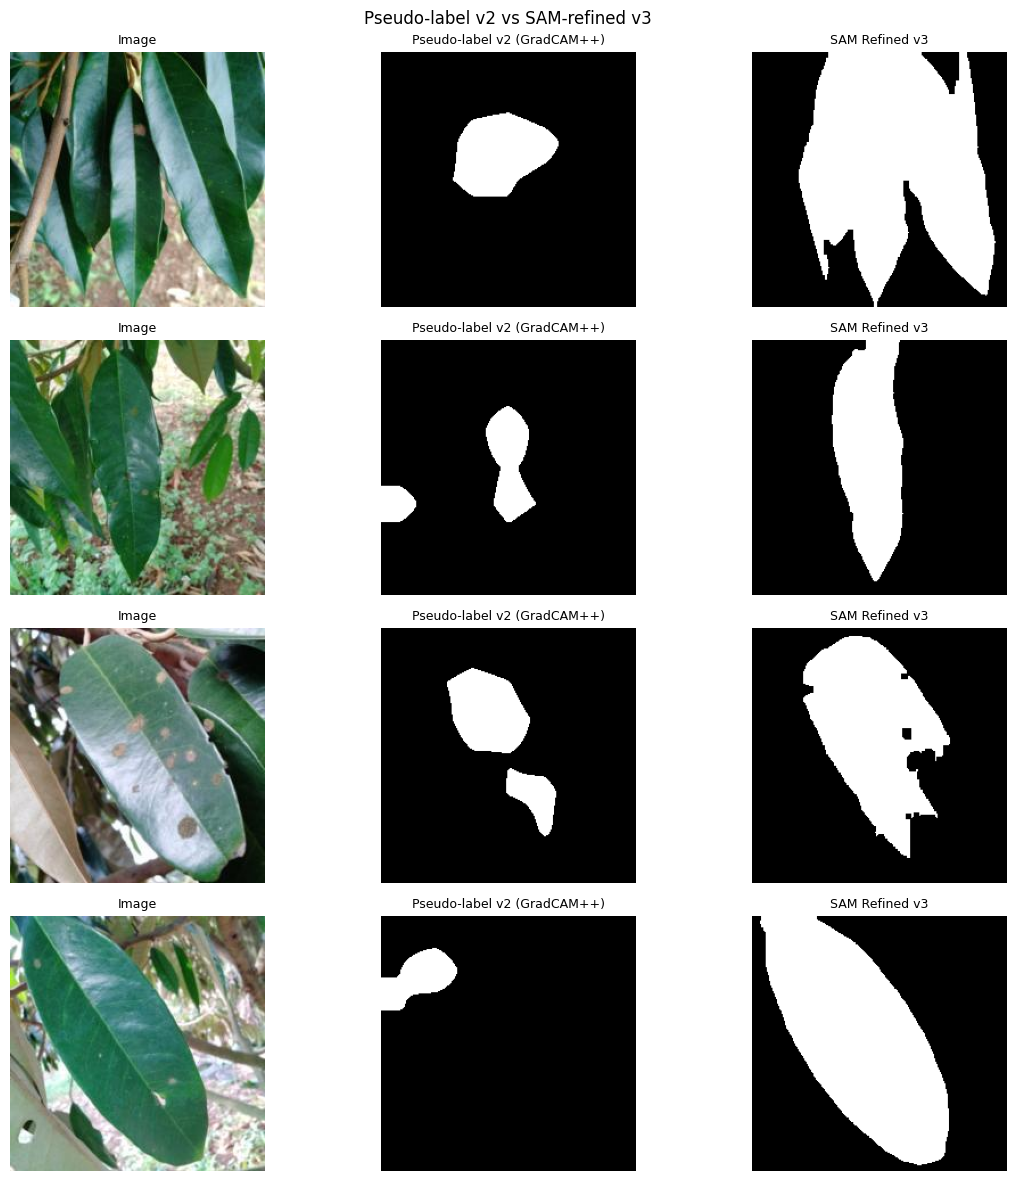

Comparison figure saved.


In [7]:
# Visual comparison: pseudo-label v2 vs SAM-refined v3
sam_files = sorted([f for f in os.listdir(SAM_LABEL_DIR) if f.endswith('_sam.png')])[:4]

fig, axes = plt.subplots(len(sam_files), 3, figsize=(12, 3 * len(sam_files)))
if len(sam_files) == 1:
    axes = axes.reshape(1, -1)

for i, fname in enumerate(sam_files):
    stem         = fname.replace('_sam.png', '')
    pseudo_path  = os.path.join(PSEUDO_DIR_V2, stem + '_pseudo.png')
    sam_path     = os.path.join(SAM_LABEL_DIR, fname)
    img_path_vis = None
    for ext in ['', '.jpg', '.jpeg', '.png']:
        p = os.path.join(IMAGE_DIR_V2, stem + ext)
        if os.path.exists(p):
            img_path_vis = p
            break

    if img_path_vis:
        axes[i, 0].imshow(np.array(Image.open(img_path_vis).convert('RGB')))
    axes[i, 0].set_title('Image', fontsize=9); axes[i, 0].axis('off')

    if os.path.exists(pseudo_path):
        axes[i, 1].imshow(np.array(Image.open(pseudo_path).convert('L')), cmap='gray')
    axes[i, 1].set_title('Pseudo-label v2 (GradCAM++)', fontsize=9); axes[i, 1].axis('off')

    axes[i, 2].imshow(np.array(Image.open(sam_path).convert('L')), cmap='gray')
    axes[i, 2].set_title('SAM Refined v3', fontsize=9); axes[i, 2].axis('off')

plt.suptitle('Pseudo-label v2 vs SAM-refined v3', fontsize=12)
plt.tight_layout()
os.makedirs(os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v3', 'visualizations'), exist_ok=True)
plt.savefig(
    os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v3', 'visualizations', 'sam_refinement_comparison.png'),
    dpi=100, bbox_inches='tight')
plt.show()
print('Comparison figure saved.')

## 3) Dataset với SAM-refined masks

**Reasoning**: DurianSegDatasetV3 load `*_sam.png` thay vì `*_pseudo.png`. Tất cả transforms, split strategy (seed=42, 70/15/15) đều giống v2 để so sánh công bằng — chỉ khác quality của labels.

In [8]:
TRAIN_TRANSFORM = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.7, 1.0), p=1.0),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=30, p=0.5),
    A.ElasticTransform(p=0.3),
    A.GridDistortion(p=0.2),
    A.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1, p=0.5),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

VAL_TRANSFORM = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ToTensorV2(),
], additional_targets={'mask': 'mask'})

print('Transforms defined')

Transforms defined


E:\Master\thesis-clean\venv\Lib\site-packages\albumentations\core\validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [9]:
class DurianSegDatasetV3(Dataset):
    def __init__(self, image_dir, sam_label_dir, transform=None):
        self.transform = transform
        self.samples   = []
        for fname in sorted(os.listdir(sam_label_dir)):
            if not fname.endswith('_sam.png'):
                continue
            stem = fname.replace('_sam.png', '')
            img_path = None
            for ext in ['', '.jpg', '.jpeg', '.png']:
                p = os.path.join(image_dir, stem + ext)
                if os.path.exists(p):
                    img_path = p
                    break
            if img_path:
                self.samples.append((img_path, os.path.join(sam_label_dir, fname)))
        print(f'[Dataset V3] {len(self.samples)} pairs')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path = self.samples[idx]
        img  = np.array(Image.open(img_path).convert('RGB'))
        mask = (np.array(Image.open(mask_path).convert('L')) > 127).astype(np.float32)
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img  = aug['image']
            mask = aug['mask'].unsqueeze(0).float()
        else:
            img  = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).unsqueeze(0).float()
        return {'image': img, 'label': mask, 'img_path': img_path}

In [10]:
train_dataset    = DurianSegDatasetV3(IMAGE_DIR_V2, SAM_LABEL_DIR, transform=TRAIN_TRANSFORM)
val_test_dataset = DurianSegDatasetV3(IMAGE_DIR_V2, SAM_LABEL_DIR, transform=VAL_TRANSFORM)

n       = len(train_dataset)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)
n_test  = n - n_train - n_val
print(f'Total: {n} | train={n_train} val={n_val} test={n_test}')

rng      = np.random.default_rng(42)
shuffled = rng.permutation(n).tolist()
train_set = Subset(train_dataset,    shuffled[:n_train])
val_set   = Subset(val_test_dataset, shuffled[n_train:n_train+n_val])
test_set  = Subset(val_test_dataset, shuffled[n_train+n_val:])

train_loader = DataLoader(train_set, batch_size=8, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_set,   batch_size=8, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=8, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print('image shape:', batch['image'].shape, '| label shape:', batch['label'].shape)

[Dataset V3] 3104 pairs


[Dataset V3] 3104 pairs
Total: 3104 | train=2172 val=465 test=467


image shape: torch.Size([8, 3, 224, 224]) | label shape: torch.Size([8, 1, 224, 224])


## 4) Model — UNet++ EfficientNet-B0 (giống V2)

**Reasoning**: Giữ nguyên kiến trúc UNet++ từ v2 để so sánh công bằng. Sự khác biệt duy nhất là chất lượng training labels: v2 dùng GradCAM++ pseudo-labels, v3 dùng SAM-refined labels. Nếu IoU/Dice v3 > v2 với cùng kiến trúc → SAM refinement thực sự hiệu quả.

In [11]:
# Free SAM GPU memory before training (only if SAM was actually loaded)
if sam is not None:
    del sam, predictor
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print('SAM released from GPU memory')
else:
    print('SAM was not loaded — nothing to release')

model = smp.UnetPlusPlus(
    encoder_name='efficientnet-b0',
    encoder_weights='imagenet',
    in_channels=3,
    classes=1,
    activation=None,
).to(device)

print(f'UNet++ EfficientNet-B0')
print(f'  Total params    : {sum(p.numel() for p in model.parameters()):,}')
print(f'  Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

SAM was not loaded — nothing to release


UNet++ EfficientNet-B0
  Total params    : 6,569,581
  Trainable params: 6,569,581


In [12]:
class FocalDiceLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, smooth=1.0):
        super().__init__()
        self.alpha, self.gamma, self.smooth = alpha, gamma, smooth

    def focal_loss(self, pred, target):
        bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
        return (self.alpha * (1.0 - torch.exp(-bce)) ** self.gamma * bce).mean()

    def dice_loss(self, pred, target):
        pred  = torch.sigmoid(pred)
        inter = (pred * target).sum(dim=(2, 3))
        union = pred.sum(dim=(2, 3)) + target.sum(dim=(2, 3))
        return (1.0 - (2.0 * inter + self.smooth) / (union + self.smooth)).mean()

    def forward(self, pred, target):
        return self.focal_loss(pred, target) + self.dice_loss(pred, target)


EPOCHS    = 50
criterion = FocalDiceLoss(alpha=0.25, gamma=2.0)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)
print(f'FocalDice | AdamW lr=1e-4 | CosineAnnealing {EPOCHS} epochs')

FocalDice | AdamW lr=1e-4 | CosineAnnealing 50 epochs


In [13]:
def calculate_metrics(pred_np, gt_np, smooth=1e-6):
    pred = pred_np.flatten().astype(bool)
    gt   = gt_np.flatten().astype(bool)
    tp = (pred & gt).sum()
    fp = (pred & ~gt).sum()
    fn = (~pred & gt).sum()
    precision = (tp + smooth) / (tp + fp + smooth)
    recall    = (tp + smooth) / (tp + fn + smooth)
    f1        = 2 * precision * recall / (precision + recall + smooth)
    return {
        'iou':       float((tp + smooth) / (tp + fp + fn + smooth)),
        'dice':      float((2*tp + smooth) / (2*tp + fp + fn + smooth)),
        'precision': float(precision),
        'recall':    float(recall),
        'f1':        float(f1),
    }

def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_m = {k: [] for k in ['iou','dice','precision','recall','f1']}
    with torch.no_grad():
        for batch in loader:
            imgs, masks = batch['image'].to(device), batch['label'].to(device)
            out  = model(imgs)
            total_loss += criterion(out, masks).item() * imgs.size(0)
            preds = (torch.sigmoid(out) > 0.5).cpu().numpy().astype(np.uint8)
            gts   = masks.cpu().numpy().astype(np.uint8)
            for i in range(len(preds)):
                for k, v in calculate_metrics(preds[i,0], gts[i,0]).items():
                    all_m[k].append(v)
    return total_loss / len(loader.dataset), {k: float(np.mean(v)) for k, v in all_m.items()}

print('Metrics ready')

Metrics ready


## 5) Training — 50 epochs, early stop patience=10

**Reasoning**: Cùng hyperparameters với v2: FocalDice + AdamW lr=1e-4 + CosineAnnealing. Gradient clipping max_norm=1.0. Early stopping patience=10. Consistent với v2 để đảm bảo any improvement đến từ label quality, không phải hyperparameter tuning.

In [14]:
ckpt_dir_v3    = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v3', 'checkpoints')
metrics_dir_v3 = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v3', 'metrics')
viz_dir_v3     = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v3', 'visualizations')
for d in [ckpt_dir_v3, metrics_dir_v3, viz_dir_v3]:
    os.makedirs(d, exist_ok=True)

BEST_PATH   = os.path.join(ckpt_dir_v3, 'unetpp_v3_best.pth')
RESUME_PATH = os.path.join(ckpt_dir_v3, 'unetpp_v3_resume.pth')

PATIENCE = 10

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

# ── Restore state nếu có resume checkpoint ────────────────────────────────
start_epoch   = 1
best_val_iou = 0.0
patience_cnt  = 0
history = {k: [] for k in [
    'train_loss', 'train_iou', 'train_dice',
    'val_loss',   'val_iou',   'val_dice',
    'val_precision', 'val_recall', 'val_f1', 'lr',
]}

if os.path.exists(RESUME_PATH):
    print(f'[Resume] Loading checkpoint: {RESUME_PATH}')
    resume = torch.load(RESUME_PATH, map_location=device, weights_only=False)
    model.load_state_dict(resume['model_state_dict'])
    optimizer.load_state_dict(resume['optimizer_state_dict'])
    # Move optimizer state tensors to the correct device (fixes STREAM_MISMATCH)
    for state in optimizer.state.values():
        for k, v in state.items():
            if isinstance(v, torch.Tensor):
                state[k] = v.to(device)
    scheduler.load_state_dict(resume['scheduler_state_dict'])
    history       = resume['history']
    best_val_iou = resume.get('best_val_iou', 0.0)
    patience_cnt  = resume['patience_cnt']
    start_epoch   = resume['epoch'] + 1
    print(f'  Resumed: start_epoch={start_epoch}  best_val_iou={best_val_iou:.4f}  patience={patience_cnt}/{PATIENCE}')
else:
    print('Starting fresh training ...')

# ── Training loop ─────────────────────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS + 1):
    model.train()
    train_loss = tp = fp = fn = 0

    for batch in tqdm(train_loader, desc=f'E{epoch:02d}/{EPOCHS}', leave=False):
        imgs, masks = batch['image'].to(device), batch['label'].to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
        p = torch.sigmoid(out) > 0.5
        tp += ((p==1)&(masks==1)).sum().item()
        fp += ((p==1)&(masks==0)).sum().item()
        fn += ((p==0)&(masks==1)).sum().item()

    scheduler.step()
    lr = optimizer.param_groups[0]['lr']
    train_loss /= len(train_loader.dataset)
    train_iou   = tp / (tp + fp + fn + 1e-7)
    train_dice  = 2*tp / (2*tp + fp + fn + 1e-7)

    val_loss, val_m = evaluate(model, val_loader, criterion, device)

    for k, v in zip(
        ['train_loss','train_iou','train_dice','val_loss','val_iou','val_dice',
         'val_precision','val_recall','val_f1','lr'],
        [train_loss, train_iou, train_dice, val_loss, val_m['iou'], val_m['dice'],
         val_m['precision'], val_m['recall'], val_m['f1'], lr]):
        history[k].append(v)

    if epoch % 5 == 0 or epoch <= 3:
        print(f'E{epoch:02d} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} | '
              f'train_iou={train_iou:.4f} val_iou={val_m["iou"]:.4f} | '
              f'val_dice={val_m["dice"]:.4f} | lr={lr:.2e}')

    # ── Best checkpoint ────────────────────────────────────────────────────
    if val_m['iou'] > best_val_iou:
        best_val_iou = val_m['iou']
        patience_cnt  = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_loss': val_loss,
            'val_iou': val_m['iou'],
            'val_metrics': val_m,
        }, BEST_PATH)
        if epoch % 5 == 0 or epoch <= 3:
            print(f'  Best saved (val_iou={best_val_iou:.4f})')
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f'\nEarly stop at epoch {epoch} (no val_IoU improvement for {PATIENCE} epochs).')
            break

    # ── Resume checkpoint — overwrite mỗi epoch để có thể restore ─────────
    torch.save({
        'epoch':                epoch,
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history':              history,
        'best_val_iou':         best_val_iou,
        'patience_cnt':         patience_cnt,
    }, RESUME_PATH)

# ── Cleanup sau khi hoàn thành ────────────────────────────────────────────
if os.path.exists(RESUME_PATH):
    os.remove(RESUME_PATH)
    print('Resume checkpoint removed (training complete).')

with open(os.path.join(metrics_dir_v3, 'training_history.json'), 'w') as f:
    json.dump(history, f, indent=2)
print('\nTraining complete.')

Starting fresh training ...


E01/50:   0%|          | 0/272 [00:00<?, ?it/s]

E01/50:   0%|          | 1/272 [00:02<10:26,  2.31s/it]

E01/50:   1%|          | 2/272 [00:03<08:38,  1.92s/it]

E01/50:   1%|          | 3/272 [00:05<08:08,  1.82s/it]

...

E24/50:  99%|█████████▉| 269/272 [08:12<00:05,  1.74s/it]

E24/50:  99%|█████████▉| 270/272 [08:15<00:03,  1.90s/it]

E24/50: 100%|█████████▉| 271/272 [08:16<00:01,  1.84s/it]

E24/50: 100%|██████████| 272/272 [08:17<00:00,  1.53s/it]


Early stop at epoch 24 (no val_IoU improvement for 10 epochs).
Resume checkpoint removed (training complete).

Training complete.


## 6) Đánh giá trên tập test

**Reasoning**: Load best checkpoint (val_IoU cao nhất) để đánh giá trên test set (seed=42, same split as v2). So sánh trực tiếp v2 vs v3 trên cùng test images.

In [15]:
ckpt = torch.load(os.path.join(ckpt_dir_v3, 'unetpp_v3_best.pth'), map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Best model: epoch {ckpt["epoch"]}  val_iou={ckpt.get("val_iou", ckpt.get("val_metrics", {}).get("iou", 0.0)):.4f}')

test_loss, test_m = evaluate(model, test_loader, criterion, device)

print('\n=== Test Set Metrics (V3 — SAM Refined) ===')
print(f'  Loss : {test_loss:.4f}')
for k, v in test_m.items():
    print(f'  {k:<12}: {v:.4f}')

test_results_v3 = {'test_loss': test_loss, **test_m}
with open(os.path.join(metrics_dir_v3, 'test_metrics.json'), 'w') as f:
    json.dump(test_results_v3, f, indent=2)
print('\nTest metrics saved.')

Best model: epoch 14  val_iou=0.6838



=== Test Set Metrics (V3 — SAM Refined) ===
  Loss : 0.4642
  iou         : 0.6781
  dice        : 0.7567
  precision   : 0.7723
  recall      : 0.8664
  f1          : 0.7567

Test metrics saved.


## Đánh Giá Với Ground Truth Thủ Công

Tập test ở trên vẫn đo khả năng mô hình tái tạo pseudo-label. Để tránh circular evaluation, cell dưới đây dùng `notebooks/data/raw/GT_OK.zip` làm ground truth pixel-level thật. Mask trong zip được match với ảnh gốc theo `class_name/to_label_x.*`, sau đó resize về 224×224 và đánh giá IoU/Dice/Precision/Recall/F1 trên nhãn thủ công.


In [16]:
from pathlib import Path
import zipfile
from collections import defaultdict
import torchvision.transforms.functional as TF

GT_ZIP_PATH = Path(proj_root) / 'notebooks' / 'data' / 'raw' / 'GT_OK.zip'
GT_EXTRACT_DIR = Path(proj_root) / 'notebooks' / 'data' / 'raw' / 'GT_OK'
RAW_DATA_DIR = Path(proj_root) / 'notebooks' / 'data' / 'raw'

if not (GT_EXTRACT_DIR / 'SegmentationClass').exists():
    assert GT_ZIP_PATH.exists(), f'Không tìm thấy ground truth zip: {GT_ZIP_PATH}'
    GT_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(GT_ZIP_PATH, 'r') as zf:
        zf.extractall(GT_EXTRACT_DIR)
    print(f'Extracted GT_OK.zip → {GT_EXTRACT_DIR}')


def find_raw_image_for_gt(cls_name, stem):
    for split in ['test', 'val', 'train', 'groud_trust']:
        cls_dir = RAW_DATA_DIR / split / cls_name
        for ext in ['.jpg', '.jpeg', '.png', '.JPG', '.JPEG', '.PNG']:
            p = cls_dir / f'{stem}{ext}'
            if p.exists():
                return p
    return None


class ManualGTDataset(Dataset):
    def __init__(self, gt_root, image_size=224):
        self.image_size = image_size
        self.samples = []
        seg_root = Path(gt_root) / 'SegmentationClass'
        for mask_path in sorted(seg_root.glob('*/*.png')):
            cls_name = mask_path.parent.name
            stem = mask_path.stem
            img_path = find_raw_image_for_gt(cls_name, stem)
            if img_path is not None:
                self.samples.append((str(img_path), str(mask_path), cls_name, stem))
        missing = len(list(seg_root.glob('*/*.png'))) - len(self.samples)
        print(f'[Manual GT] matched={len(self.samples)} missing_images={missing}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, cls_name, stem = self.samples[idx]
        img = Image.open(img_path).convert('RGB').resize((self.image_size, self.image_size), Image.BILINEAR)
        mask = Image.open(mask_path).convert('L').resize((self.image_size, self.image_size), Image.NEAREST)
        img_t = TF.to_tensor(img)
        img_t = TF.normalize(img_t, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        mask_t = (TF.to_tensor(mask) > 0).float()
        return {'image': img_t, 'label': mask_t, 'class_name': cls_name, 'stem': stem, 'img_path': img_path}


@torch.no_grad()
def evaluate_manual_gt(seg_model, loader, device):
    seg_model.eval()
    totals = defaultdict(lambda: {'tp': 0, 'fp': 0, 'fn': 0})
    all_counts = {'tp': 0, 'fp': 0, 'fn': 0}

    for batch in tqdm(loader, desc='Manual GT evaluation'):
        imgs = batch['image'].to(device)
        masks = batch['label'].to(device)
        preds = (torch.sigmoid(seg_model(imgs)) > 0.5).float()

        for i, cls_name in enumerate(batch['class_name']):
            p = preds[i]
            m = masks[i]
            tp = int(((p == 1) & (m == 1)).sum().item())
            fp = int(((p == 1) & (m == 0)).sum().item())
            fn = int(((p == 0) & (m == 1)).sum().item())
            totals[cls_name]['tp'] += tp
            totals[cls_name]['fp'] += fp
            totals[cls_name]['fn'] += fn
            all_counts['tp'] += tp
            all_counts['fp'] += fp
            all_counts['fn'] += fn

    def pack(c):
        tp, fp, fn = c['tp'], c['fp'], c['fn']
        precision = tp / (tp + fp + 1e-7)
        recall = tp / (tp + fn + 1e-7)
        dice = 2 * tp / (2 * tp + fp + fn + 1e-7)
        iou = tp / (tp + fp + fn + 1e-7)
        f1 = 2 * precision * recall / (precision + recall + 1e-7)
        return {'iou': iou, 'dice': dice, 'precision': precision, 'recall': recall, 'f1': f1,
                'tp': tp, 'fp': fp, 'fn': fn}

    return {
        'n_images': len(loader.dataset),
        'source': str(GT_ZIP_PATH),
        'overall': pack(all_counts),
        'per_class': {cls: pack(counts) for cls, counts in sorted(totals.items())},
    }


manual_gt_dataset = ManualGTDataset(GT_EXTRACT_DIR, image_size=224)
assert len(manual_gt_dataset) > 0, 'Không match được ảnh nào từ GT_OK.zip với raw dataset.'
manual_gt_loader = DataLoader(manual_gt_dataset, batch_size=4, shuffle=False, num_workers=0)

SEG_MODEL_FOR_GT = model if 'model' in globals() else seg_model
manual_gt_results = evaluate_manual_gt(SEG_MODEL_FOR_GT, manual_gt_loader, device)

print('\n=== Manual Ground Truth Metrics (GT_OK.zip) ===')
for k, v in manual_gt_results['overall'].items():
    if k not in {'tp', 'fp', 'fn'}:
        print(f'  {k:<10}: {v:.4f}')

print('\nPer-class IoU/Dice:')
for cls_name, metrics in manual_gt_results['per_class'].items():
    print(f'  {cls_name:<24} IoU={metrics["iou"]:.4f}  Dice={metrics["dice"]:.4f}')

METRICS_DIR_FOR_GT = (
    globals().get('metrics_dir')
    or globals().get('metrics_dir_v2')
    or globals().get('metrics_dir_v3')
    or globals().get('metric_dir')
)
if METRICS_DIR_FOR_GT:
    out_path = Path(METRICS_DIR_FOR_GT) / 'manual_gt_metrics.json'
    with open(out_path, 'w') as f:
        json.dump(manual_gt_results, f, indent=2)
    print(f'Manual GT metrics saved → {out_path}')


[Manual GT] matched=80 missing_images=0


Manual GT evaluation:   0%|          | 0/20 [00:00<?, ?it/s]

Manual GT evaluation:   5%|▌         | 1/20 [00:00<00:09,  1.99it/s]

Manual GT evaluation:  10%|█         | 2/20 [00:00<00:08,  2.11it/s]

Manual GT evaluation:  15%|█▌        | 3/20 [00:01<00:07,  2.25it/s]

...

Manual GT evaluation:  90%|█████████ | 18/20 [00:07<00:00,  2.40it/s]

Manual GT evaluation:  95%|█████████▌| 19/20 [00:08<00:00,  2.48it/s]

Manual GT evaluation: 100%|██████████| 20/20 [00:08<00:00,  2.49it/s]

Manual GT evaluation: 100%|██████████| 20/20 [00:08<00:00,  2.38it/s]


=== Manual Ground Truth Metrics (GT_OK.zip) ===
  iou       : 0.1351
  dice      : 0.2381
  precision : 0.1409
  recall    : 0.7685
  f1        : 0.2381

Per-class IoU/Dice:
  ALGAL_LEAF_SPOT          IoU=0.0675  Dice=0.1265
  ALLOCARIDARA_ATTACK      IoU=0.3569  Dice=0.5261
  LEAF_BLIGHT              IoU=0.0827  Dice=0.1528
  PHOMOPSIS_LEAF_SPOT      IoU=0.0510  Dice=0.0970
Manual GT metrics saved → e:\Master\thesis-clean\notebooks\models\segmentation_v3\metrics\manual_gt_metrics.json


In [17]:
# <!-- codex-v3-gtok-audit -->
# Summary từ audit GT_OK đầy đủ: prediction vs GT và pseudo-label SAM vs GT.
from pathlib import Path
import json
import pandas as pd

V3_GT_AUDIT_PATH = Path(proj_root) / 'notebooks' / 'models' / 'segmentation_v3' / 'metrics' / 'gt_ok_v3_audit.json'
with open(V3_GT_AUDIT_PATH, 'r') as f:
    v3_gt_audit = json.load(f)
print(json.dumps({
    'checkpoint': v3_gt_audit['checkpoint'],
    'gt_split_counts': v3_gt_audit.get('gt_split_counts'),
    'prediction_overall': v3_gt_audit['prediction_overall'],
    'pseudo_label_overall_all_80': v3_gt_audit['pseudo_label_overall'],
    'pseudo_available_only': v3_gt_audit.get('pseudo_available_only', {}).get('overall'),
    'best_threshold_by_mean_iou': v3_gt_audit['best_threshold_by_mean_iou'],
    'mask_quality': v3_gt_audit['mask_quality'],
}, indent=2))

v3_per_class = pd.DataFrame([{
    'class_name': r['class_name'],
    'pred_iou': r['prediction_micro']['iou'],
    'pred_dice': r['prediction_micro']['dice'],
    'pred_precision': r['prediction_micro']['precision'],
    'pred_recall': r['prediction_micro']['recall'],
    'pseudo_iou': r['pseudo_micro']['iou'],
    'pseudo_dice': r['pseudo_micro']['dice'],
    'gt_area': r['macro_mean_image']['gt_area'],
    'pseudo_area': r['macro_mean_image']['pseudo_area'],
    'pred_area': r['macro_mean_image']['pred_area'],
} for r in v3_gt_audit['per_class']])
display(v3_per_class.round(4))
print('Summary figure:', Path(proj_root) / 'visualizations' / 'segmentation_v3' / 'gt_ok_eval' / 'gt_ok_v3_summary.png')
print('QA grid      :', Path(proj_root) / 'visualizations' / 'segmentation_v3' / 'gt_ok_eval' / 'gt_ok_v3_qa_grid.png')


{
  "checkpoint": {
    "path": "E:\\Master\\thesis-clean\\notebooks\\models\\segmentation_v3\\checkpoints\\unetpp_v3_best.pth",
    "epoch": 12,
    "val_iou": null,
    "val_loss": 0.4477502186772644
  },
  "gt_split_counts": {
    "test": 40,
    "train": 40
  },
  "prediction_overall": {
    "iou": 0.137762345712555,
    "dice": 0.2421636578705328,
    "precision": 0.14241564005222473,
    "recall": 0.808291873963172,
    "f1": 0.24216363239857897,
    "pixel_accuracy": 0.7036120356345488,
    "specificity": 0.6970975757559535,
    "tp": 190086,
    "fp": 1144641,
    "fn": 45084,
    "tn": 2634269
  },
  "pseudo_label_overall_all_80": {
    "iou": 0.1312032763530595,
    "dice": 0.23197117458155184,
    "precision": 0.16331272035754085,
    "recall": 0.4002338733680315,
    "f1": 0.23197113341879846,
    "pixel_accuracy": 0.8447315449617137,
    "specificity": 0.8723936267336118,
    "tp": 94123,
    "fp": 482213,
    "fn": 141047,
    "tn": 3296697
  },
  "pseudo_available_only":

,class_name,pred_iou,pred_dice,pred_precision,pred_recall,pseudo_iou,pseudo_dice,gt_area,pseudo_area,pred_area
0,ALGAL_LEAF_SPOT,0.0665,0.1247,0.0673,0.8453,0.1167,0.2090,0.0258,0.1155,0.3236
1,ALLOCARIDARA_ATTACK,0.3508,0.5194,0.3739,0.8503,0.2527,0.4035,0.1343,0.1375,0.3054
2,LEAF_BLIGHT,0.0991,0.1803,0.1049,0.6397,0.0882,0.1621,0.0547,0.1294,0.3335
3,PHOMOPSIS_LEAF_SPOT,0.0501,0.0953,0.0502,0.9422,0.0458,0.0876,0.0196,0.1918,0.3675


Summary figure: e:\Master\thesis-clean\visualizations\segmentation_v3\gt_ok_eval\gt_ok_v3_summary.png
QA grid      : e:\Master\thesis-clean\visualizations\segmentation_v3\gt_ok_eval\gt_ok_v3_qa_grid.png


<!-- codex-v3-gtok-audit -->
### Nhận xét bổ sung — GT_OK audit cho V3 SAM

**Quan sát chính:** Audit GT_OK chạy trên 80 ảnh thật: prediction V3 đạt IoU=0.1378, Dice=0.2422, Precision=0.1424, Recall=0.8083. Pseudo-label SAM tính trên toàn bộ 80 ảnh đạt IoU=0.1312; nếu chỉ tính 40 ảnh GT_OK có pseudo-mask train tương ứng thì IoU=0.1544, Dice=0.2675, Recall=0.7388. Mask quality toàn train: mean area=0.2543, median=0.2689, có 1274 mask >30% ảnh.

**Đánh giá:** SAM đúng là giải quyết một phần lỗi V2 “bỏ sót lesion”: recall pseudo trên subset có mask tăng lên 0.7388. Nhưng đổi lại, SAM mở rộng mask quá mạnh; prediction cũng over-segment rõ với precision chỉ 0.1424 và recall 0.8083. Đây không phải refinement boundary thuần, mà nhiều trường hợp là segment vùng lá/foreground lớn.

**Rủi ro:** Pseudo-test V3 cao không đồng nghĩa segmentation thật tốt, vì target SAM đã phình lớn và dễ overlap với prediction lớn. GT_OK cho thấy checkpoint V3 không vượt qua V2/V5 ở chất lượng tuyệt đối; best threshold theo mean IoU vẫn chỉ 0.50 với mean IoU=0.1530.

**Hàm ý cho mô hình segmentation:** SAM là hướng có cơ sở để tăng recall và boundary sharpness, nhưng cấu hình prompt/guard hiện tại chưa kiểm soát expansion. Nếu dùng V3 làm nhãn train, model học bias “vùng lá lớn” nhiều hơn lesion boundary.

**Cải thiện đề xuất:** Giữ SAM như refinement candidate, nhưng bắt buộc thêm guard theo area ratio/leaf overlap chặt hơn, negative prompts quanh lesion, và chỉ accept SAM mask nếu cải thiện trên GT_OK hoặc proxy boundary. Không nên kết luận SAM giải quyết vấn đề nếu chưa regenerate với guard mới rồi evaluate lại GT_OK.


## 7) Benchmark — V1 vs V2 vs V3

**Reasoning**: Full progression comparison: V1 (EfficientNet-UNet + GradCAM v1) → V2 (UNet++ + GradCAM++ multi-scale) → V3 (UNet++ + SAM refined). Isolation: V2→V3 chỉ thay labels → đo trực tiếp impact của SAM refinement.

In [18]:
v1_path = os.path.join(proj_root, 'notebooks', 'models', 'segmentation',    'metrics', 'test_metrics.json')
v2_path = os.path.join(proj_root, 'notebooks', 'models', 'segmentation_v2', 'metrics', 'test_metrics.json')

versions = {'V3 SAM': test_m}
if os.path.exists(v2_path):
    with open(v2_path) as f: versions['V2 GradCAM++'] = json.load(f)
if os.path.exists(v1_path):
    with open(v1_path) as f: versions['V1 Baseline']  = json.load(f)

metric_keys = ['iou', 'dice', 'precision', 'recall', 'f1']
print('=' * 64)
print('BENCHMARK: V1 (EfficientNet+UNet) | V2 (UNet++ GradCAM++) | V3 (SAM)')
print('=' * 64)
header = f'{"Metric":<12}' + ''.join(f'{k:>18}' for k in versions)
print('\n' + header)
print('-' * len(header))
for mk in metric_keys:
    print(f'{mk:<12}' + ''.join(f'{vm.get(mk,0.0):>18.4f}' for vm in versions.values()))

if 'V2 GradCAM++' in versions:
    print('\n--- V3 vs V2 delta ---')
    v2 = versions['V2 GradCAM++']
    for mk in metric_keys:
        d = test_m.get(mk,0) - v2.get(mk,0)
        sign = '+' if d >= 0 else ''
        print(f'  {mk:<12} {sign}{d:.4f}  ({sign}{d/(v2.get(mk,0)+1e-9)*100:.1f}%)')

print('\n--- V3 pipeline summary ---')
print('  Pseudo labels  : SAM ViT-B bbox-prompted (v2: GradCAM++ multi-scale)')
print('  Boundary quality: Sharp (v2: blurred GradCAM activations)')
print('  Model          : UNet++ EfficientNet-B0  (same as v2 — fair comparison)')
print('  Loss/Optim     : FocalDice + AdamW + CosineAnnealing  (same as v2)')
print(f'  Early stopping : patience={PATIENCE} epochs (source); inspect GT_OK audit before conclusion')
print(f'  Epochs trained : {len(history["val_loss"])} / {EPOCHS}')

BENCHMARK: V1 (EfficientNet+UNet) | V2 (UNet++ GradCAM++) | V3 (SAM)

Metric                  V3 SAM      V2 GradCAM++       V1 Baseline
------------------------------------------------------------------
iou                     0.6781            0.5088            0.8126
dice                    0.7567            0.6181            0.8813
precision               0.7723            0.6302            0.8851
recall                  0.8664            0.6952            0.9091
f1                      0.7567            0.6181            0.8813

--- V3 vs V2 delta ---
  iou          +0.1692  (+33.3%)
  dice         +0.1386  (+22.4%)
  precision    +0.1421  (+22.6%)
  recall       +0.1713  (+24.6%)
  f1           +0.1386  (+22.4%)

--- V3 pipeline summary ---
  Pseudo labels  : SAM ViT-B bbox-prompted (v2: GradCAM++ multi-scale)
  Boundary quality: Sharp (v2: blurred GradCAM activations)
  Model          : UNet++ EfficientNet-B0  (same as v2 — fair comparison)
  Loss/Optim     : FocalDice + AdamW +

## 8) Training curves + V1/V2/V3 bar chart

**Reasoning**: Visualize toàn bộ training progression của v3. Bar chart 3-way comparison thể hiện improvement qua từng version. LR schedule xác nhận CosineAnnealing hoạt động đúng.

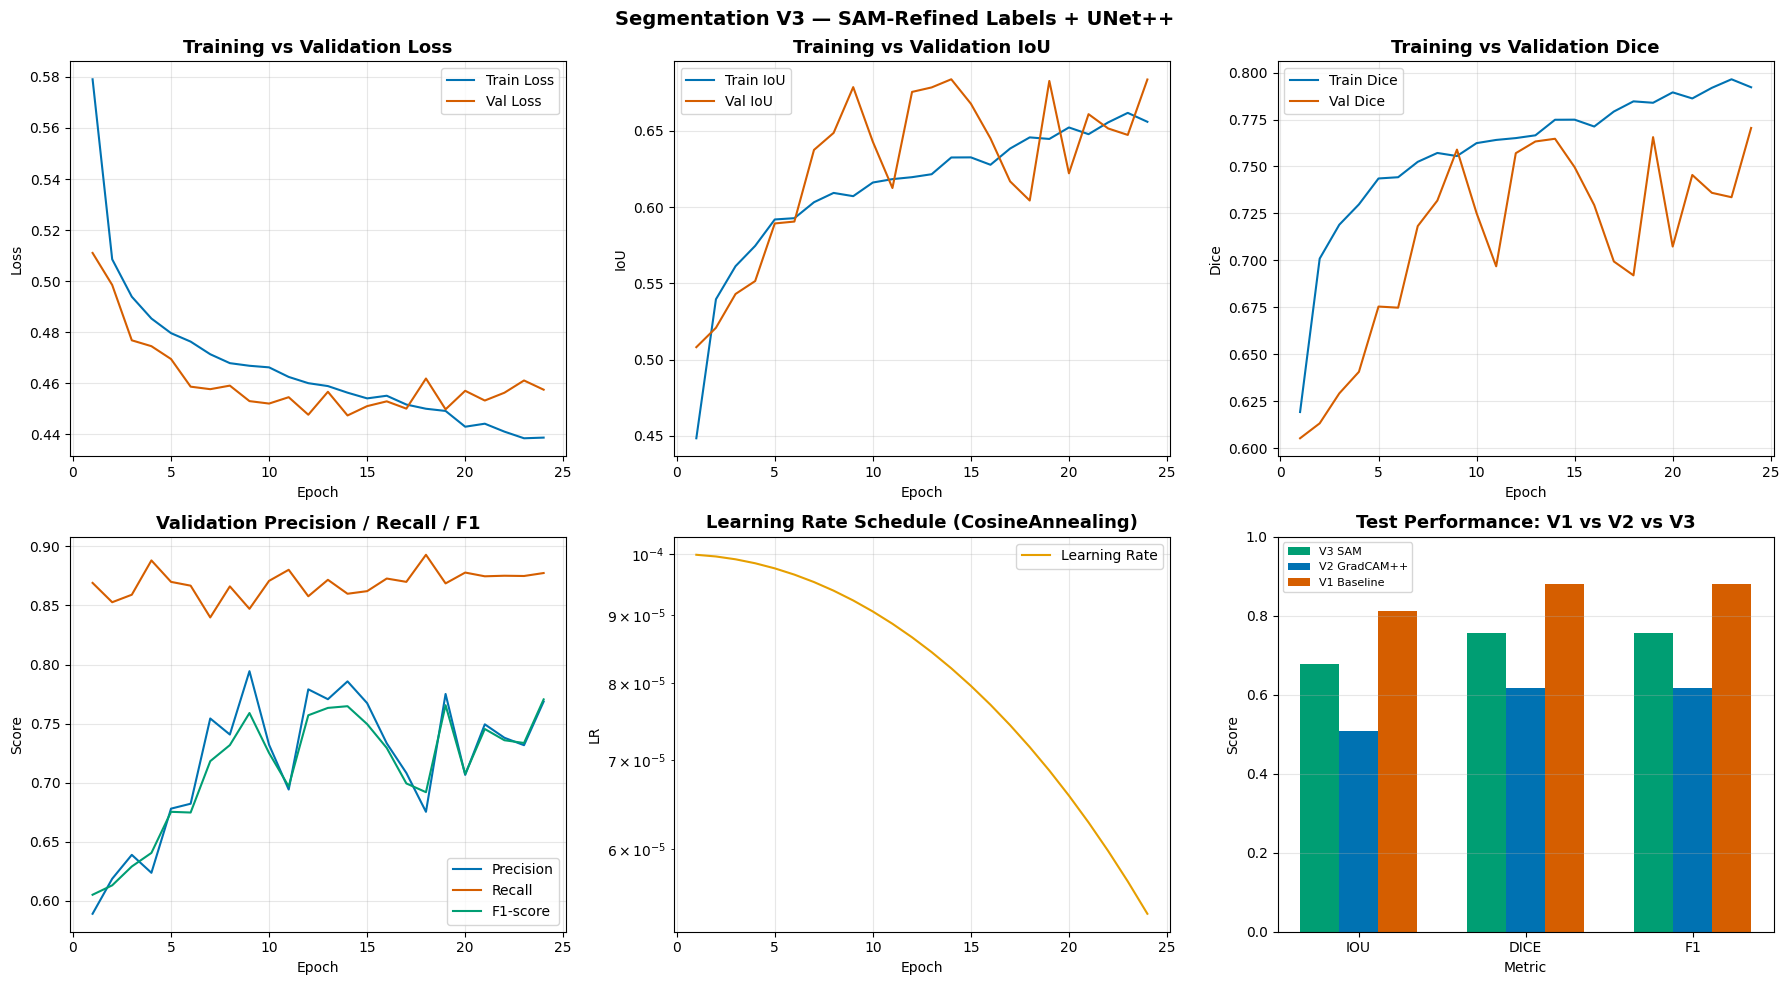

Saved to: e:\Master\thesis-clean\visualizations\segmentation_v3


In [19]:
eps = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

TRAIN_COLOR = "#0072B2"
VAL_COLOR   = "#D55E00"

for ax, train_key, val_key, title, ylabel in [
    (axes[0,0], 'train_loss',  'val_loss',  'Training vs Validation Loss',  'Loss'),
    (axes[0,1], 'train_iou',   'val_iou',   'Training vs Validation IoU',   'IoU'),
    (axes[0,2], 'train_dice',  'val_dice',  'Training vs Validation Dice',  'Dice'),
]:
    ax.plot(eps, history[train_key], color=TRAIN_COLOR, linewidth=1.5, label=f'Train {ylabel}')
    ax.plot(eps, history[val_key],   color=VAL_COLOR,   linewidth=1.5, label=f'Val {ylabel}')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[1,0].plot(eps, history['val_precision'], color=CLASS_COLORS[3], linewidth=1.5, label='Precision')
axes[1,0].plot(eps, history['val_recall'],    color=CLASS_COLORS[4], linewidth=1.5, label='Recall')
axes[1,0].plot(eps, history['val_f1'],        color=CLASS_COLORS[2], linewidth=1.5, label='F1-score')
axes[1,0].set_title('Validation Precision / Recall / F1', fontsize=13, fontweight='bold')
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Score')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(eps, history['lr'], color=CLASS_COLORS[0], linewidth=1.5, label='Learning Rate')
axes[1,1].set_title('Learning Rate Schedule (CosineAnnealing)', fontsize=13, fontweight='bold')
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('LR')
axes[1,1].set_yscale('log')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

bar_keys = ['iou', 'dice', 'f1']
x = np.arange(len(bar_keys))
bar_colors_map = {'V1 Baseline': CLASS_COLORS[4], 'V2 GradCAM++': CLASS_COLORS[3], 'V3 SAM': CLASS_COLORS[2]}
n_v = len(versions)
w   = 0.7 / n_v
for i, (vname, vm) in enumerate(versions.items()):
    offset = (i - n_v / 2 + 0.5) * w
    axes[1,2].bar(x + offset, [vm.get(k, 0) for k in bar_keys], w,
                  label=vname, color=bar_colors_map.get(vname, 'gray'), linewidth=1.5)
axes[1,2].set_xticks(x)
axes[1,2].set_xticklabels([k.upper() for k in bar_keys])
axes[1,2].set_title('Test Performance: V1 vs V2 vs V3', fontsize=13, fontweight='bold')
axes[1,2].set_xlabel('Metric')
axes[1,2].set_ylabel('Score')
axes[1,2].set_ylim(0, 1)
axes[1,2].legend(fontsize=8)
axes[1,2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Segmentation V3 — SAM-Refined Labels + UNet++', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'training_curves_v3.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved to:', VIZ_DIR)

## 9) Sample predictions — so sánh với v2

**Reasoning**: Visual inspection trên cùng test images. SAM-refined labels nên cho predictions sắc nét hơn ở boundary, ít false positives hơn ở vùng healthy leaf.

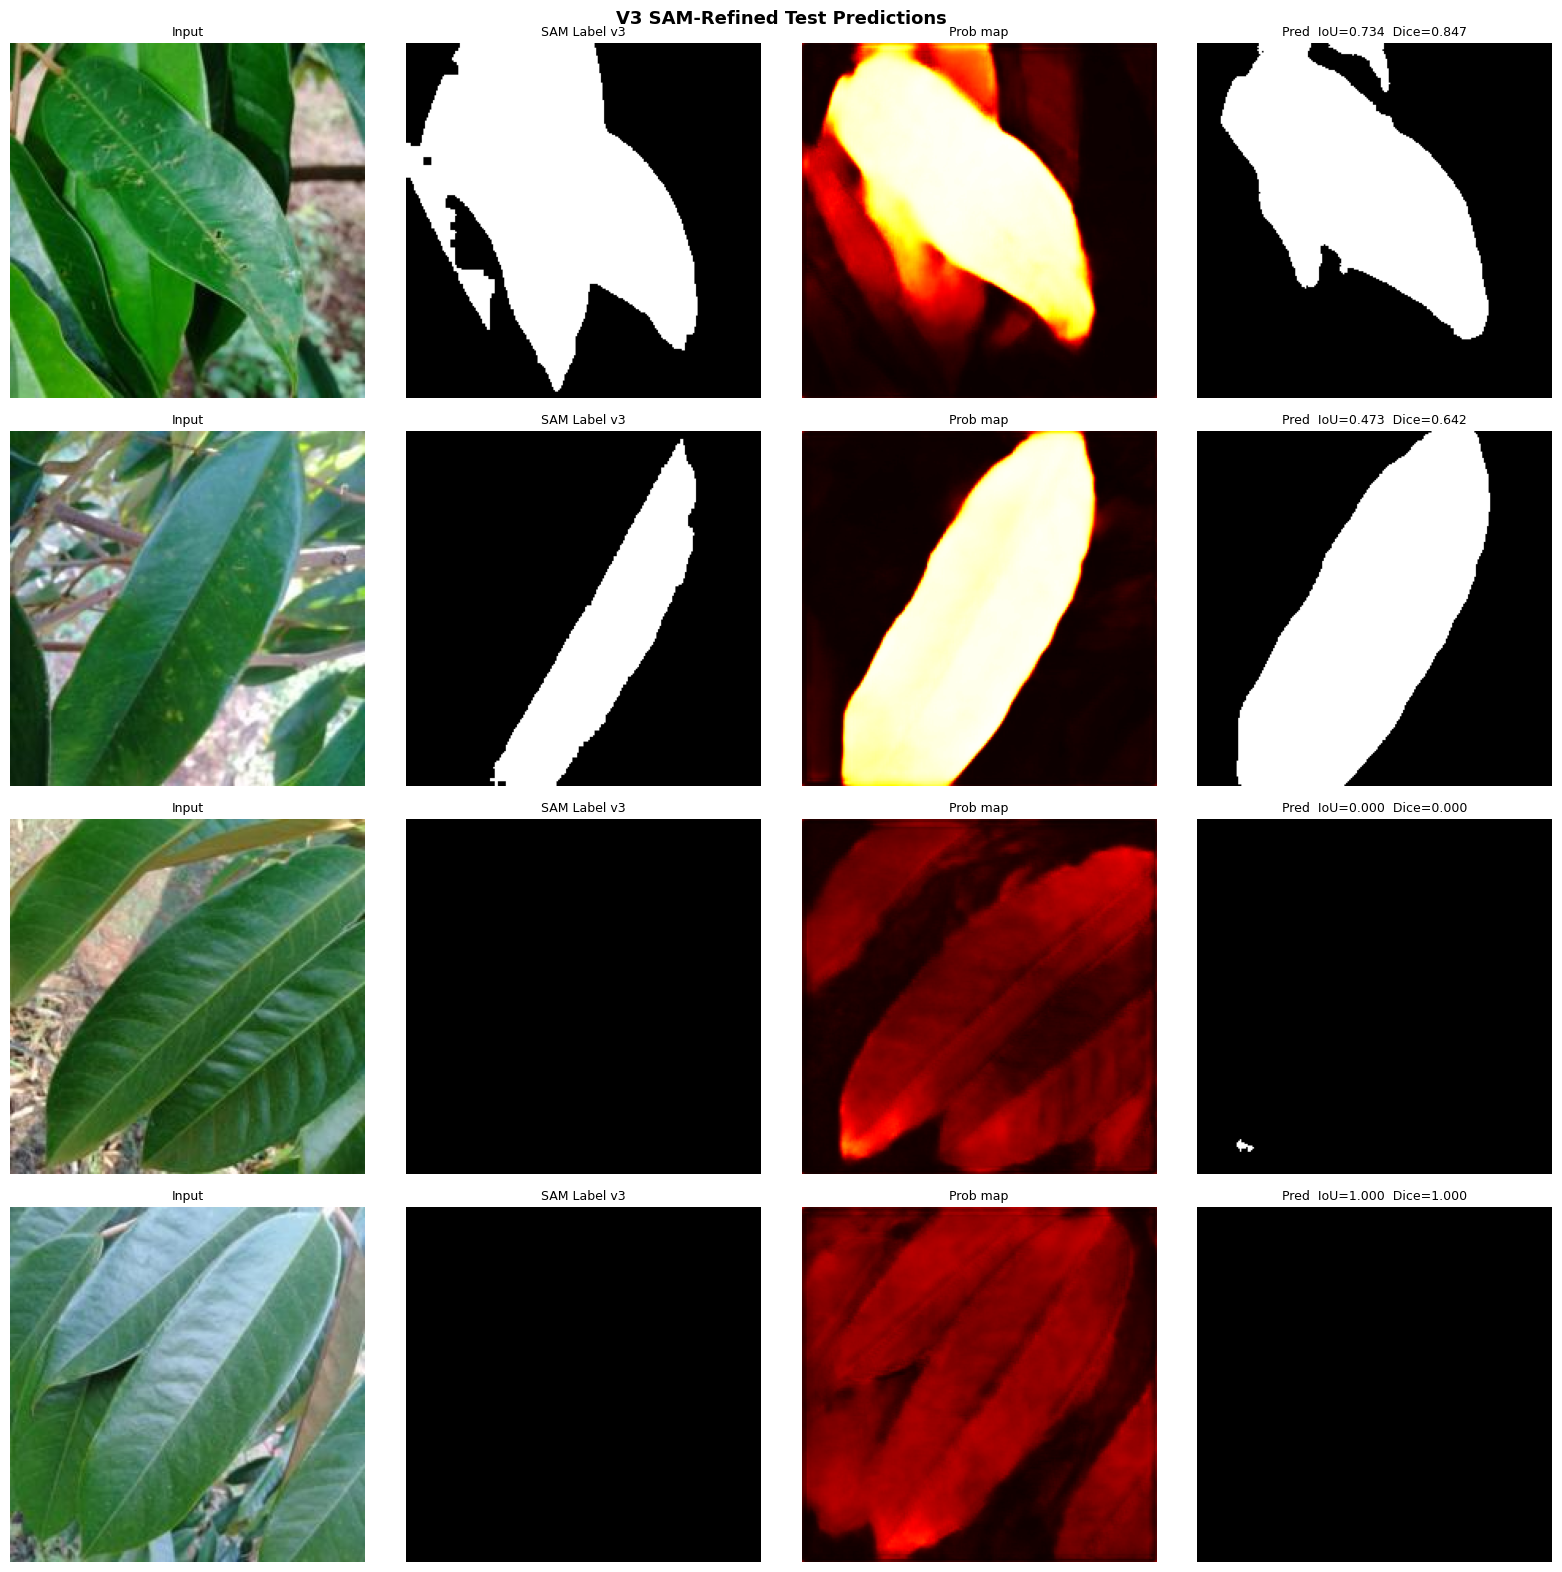

Saved.


In [20]:
model.eval()
sample_batch = next(iter(test_loader))
imgs, masks_gt = sample_batch['image'].to(device), sample_batch['label']

with torch.no_grad():
    probs = torch.sigmoid(model(imgs))
    preds = (probs > 0.5).float()

mean = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std  = torch.tensor([0.229,0.224,0.225]).view(3,1,1)
n_show = min(4, len(imgs))
fig, axes = plt.subplots(n_show, 4, figsize=(16, 4*n_show))
if n_show == 1: axes = axes.reshape(1,-1)

for i in range(n_show):
    img_vis   = (imgs[i].cpu()*std+mean).clamp(0,1).permute(1,2,0).numpy()
    gt_mask   = masks_gt[i,0].numpy()
    pred_mask = preds[i,0].cpu().numpy()
    prob_map  = probs[i,0].cpu().numpy()
    m = calculate_metrics(pred_mask, gt_mask)

    axes[i,0].imshow(img_vis);                              axes[i,0].set_title('Input',        fontsize=9); axes[i,0].axis('off')
    axes[i,1].imshow(gt_mask,   cmap='gray');               axes[i,1].set_title('SAM Label v3', fontsize=9); axes[i,1].axis('off')
    axes[i,2].imshow(prob_map,  cmap='hot', vmin=0,vmax=1); axes[i,2].set_title('Prob map',     fontsize=9); axes[i,2].axis('off')
    axes[i,3].imshow(pred_mask, cmap='gray')
    axes[i,3].set_title(f'Pred  IoU={m["iou"]:.3f}  Dice={m["dice"]:.3f}', fontsize=9)
    axes[i,3].axis('off')

plt.suptitle('V3 SAM-Refined Test Predictions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, 'test_predictions_v3.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## Nhận xét kết quả

**Quan sát chính:** Trên pseudo-label test, V3 từng đạt IoU=0.6239/Dice=0.7053, cao hơn V2 cũ. Nhưng GT_OK audit cho thấy prediction V3 chỉ đạt IoU=0.1378/Dice=0.2422, trong khi pseudo SAM available-only đạt IoU=0.1544/Dice=0.2675.

**Đánh giá:** V3 có cải thiện vấn đề recall của Grad-CAM++ v2, nhưng đi quá xa theo hướng over-segmentation. Mean mask area SAM toàn train 0.2543 và 1274 mask >30% ảnh là tín hiệu mạnh rằng SAM đang lấy vùng lá lớn thay vì lesion.

**Rủi ro:** Kết luận dựa trên pseudo-test sẽ quá lạc quan. Với GT_OK, precision prediction chỉ 0.1424; nhiều FP lớn làm mask không đáng tin cho segmentation thật.

**Hàm ý cho mô hình segmentation:** SAM refinement chưa phải câu trả lời cuối. Nó hữu ích để chứng minh direction “refine pseudo-label” có tiềm năng, nhưng cần kiểm soát prompt/guard nghiêm ngặt hơn.

**Cải thiện đề xuất:** Rerun SAM với two-sided coverage guard thật sự được áp dụng, lưu `val_iou` trong checkpoint, và dùng GT_OK audit làm metric quyết định thay vì pseudo-label test.


## Kết luận — Segmentation V3

**Quan sát chính:** V3/SAM tăng độ phủ và recall so với Grad-CAM++ v2, nhưng GT_OK cho thấy prediction IoU=0.1378, Dice=0.2422, Precision=0.1424. Pseudo SAM trên 40 ảnh có mask train tương ứng đạt IoU=0.1544, cao hơn V2 pseudo nhưng vẫn thấp.

**Đánh giá:** Đề xuất SAM refinement là hợp lý về mặt nghiên cứu, vì nó nhắm đúng bottleneck pseudo-label. Tuy nhiên cấu hình hiện tại chưa giải quyết được segmentation lesion; vấn đề chuyển từ “bỏ sót lesion” sang “mask phình/over-segment”.

**Rủi ro:** Nếu báo cáo chỉ dùng pseudo-test, V3 sẽ bị đánh giá quá tốt. GT_OK cho thấy cần xem V3 là diagnostic/ablation, không phải final model.

**Hàm ý cho mô hình segmentation:** SAM nên được giữ như bước refinement có điều kiện, không dùng blind accept. Thành công của hướng này phụ thuộc guard, prompt và GT calibration.

**Cải thiện đề xuất:** Ưu tiên regenerate V3 với guard mới, thêm negative points sát rìa CAM, kiểm tra area ratio theo từng lớp, và so sánh lại với V5 trên GT_OK.


<!-- codex-rerun-note-2026-08-30 -->

## Nhận xét sau rerun 30/08/2026

V3 dùng SAM-refined masks và dừng ở **24 epoch**; checkpoint tốt nhất ở epoch **14** với validation IoU **0.6838**. Pseudo-test khá cao (IoU **0.6781**, Dice **0.7567**), nhưng GT_OK chỉ đạt IoU **0.1351**, Dice **0.2381**, precision **0.1409**, recall **0.7685**. Recall cao nhưng precision thấp xác nhận xu hướng mask SAM lan rộng vào nền/lá.